In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv('/content/continuous dataset.csv')

df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [ ]:
features = ['nat_demand','T2M_toc','QV2M_toc','TQL_toc','W2M_toc']

data = df[features]

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
sequence_length = 168

X = []
y = []

target_index = features.index('nat_demand')

for i in range(sequence_length, len(scaled_df)):

    X.append(scaled_df.iloc[i-sequence_length:i].values)

    y.append(scaled_df.iloc[i, target_index])

X = np.array(X)
y = np.array(y)

In [ ]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0238 - val_loss: 0.0024
Epoch 2/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 3/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 9.3552e-04 - val_loss: 9.3543e-04
Epoch 4/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 6.7219e-04 - val_loss: 8.4934e-04
Epoch 5/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 5.9549e-04 - val_loss: 5.6344e-04
Epoch 6/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 4.7733e-04 - val_loss: 6.8329e-04
Epoch 7/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 4.3417e-04 - val_loss: 4.4020e-04
Epoch 8/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 3.5717e-04 - val_loss: 3.5954e-04
Epoch 9/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 3.1207e-04 - val_loss: 6.3889e-04
Epoch 10/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 3.1967e-04 - val_loss: 3.6772e-04
Epoch 11/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 2.

In [ ]:
lstm_pred_train = model.predict(X_train)
lstm_pred_test = model.predict(X_test)

1197/1197 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
train_residual = y_train - lstm_pred_train.flatten()
test_residual = y_test - lstm_pred_test.flatten()

In [ ]:
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb_model.fit(X_train_xgb, train_residual)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_residual_pred = xgb_model.predict(X_test_xgb)

In [ ]:
final_pred = lstm_pred_test.flatten() + xgb_residual_pred

In [ ]:
y_pred_full = np.zeros((len(final_pred), scaled_df.shape[1]))
y_test_full = np.zeros((len(y_test), scaled_df.shape[1]))

y_pred_full[:, target_index] = final_pred
y_test_full[:, target_index] = y_test

y_pred_inverse = scaler.inverse_transform(y_pred_full)[:, target_index]
y_test_inverse = scaler.inverse_transform(y_test_full)[:, target_index]

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_inverse, y_pred_inverse))

mae = mean_absolute_error(y_test_inverse, y_pred_inverse)

mape = np.mean(
    np.abs((y_test_inverse - y_pred_inverse)/y_test_inverse)
)*100

print("RMSE:",rmse)
print("MAE:",mae)
print("MAPE:",mape)

RMSE: 22.827186975346546
MAE: 16.503037467305212
MAPE: 1.3786562284237869


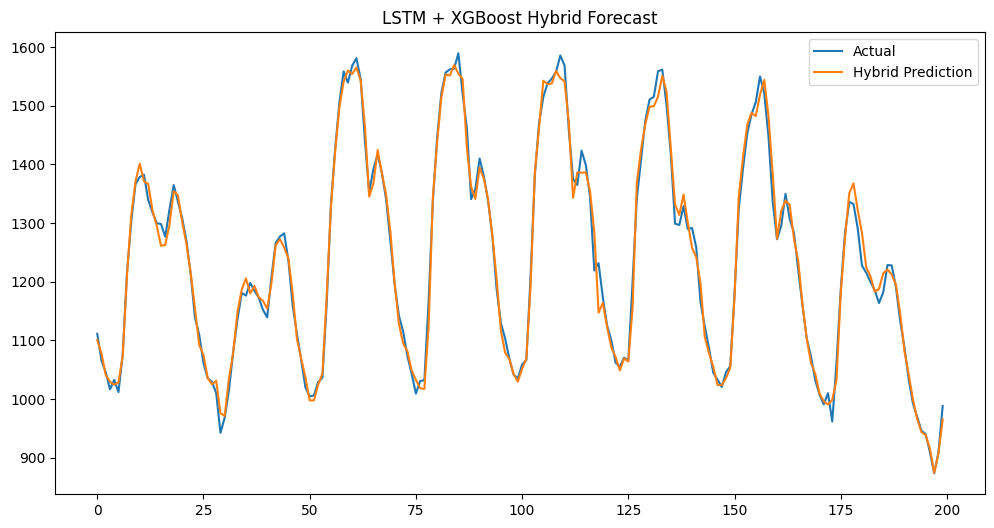

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test_inverse[:200], label="Actual")
plt.plot(y_pred_inverse[:200], label="Hybrid Prediction")

plt.legend()
plt.title("LSTM + XGBoost Hybrid Forecast")

plt.show()

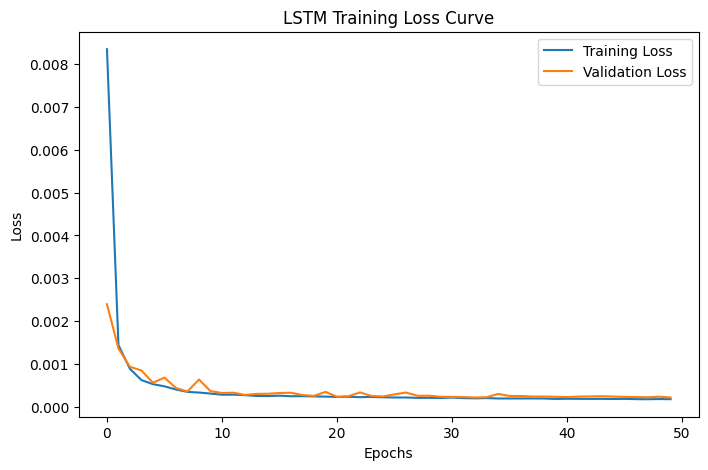

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()